# Formula 1 Top-10 Finish Prediction — Decision-Oriented EDA

This notebook analyzes race results from the 2022–2024 Formula 1 seasons to support one decision goal:
**Can we predict whether a driver will finish in the Top 10 before a race starts?**

## Workflow

1. Define and build the target (`is_top10`).
2. Answer five research questions with evidence.
3. Audit data quality and leakage risk.
4. Propose a temporal train/validation/test split.
5. Close with a 1-3-1 executive summary.

In [1]:
RANDOM_SEED = 414

import warnings
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
YEARS = [2022, 2023, 2024]

rows = []

for year in YEARS:
    schedule = fastf1.get_event_schedule(year, include_testing=False)

    for round_number in schedule["RoundNumber"].dropna().astype(int).unique():
        try:
            session = fastf1.get_session(year, round_number, "R")
            session.load(laps=False, telemetry=False, weather=False, messages=False)

            race = session.results[[
                "Abbreviation",
                "FullName",
                "TeamName",
                "GridPosition",
                "Position"
            ]].copy()

            race["season"] = year
            race["round"] = round_number
            rows.append(race)

        except Exception as e:
            print(f"Could not load {year} round {round_number}: {e}")

df = pd.concat(rows, ignore_index=True)

df = df.rename(columns={
    "Abbreviation": "driver_code",
    "FullName": "driver_name",
    "TeamName": "team_name",
    "GridPosition": "grid_position",
    "Position": "finish_position"
})

df["grid_position"] = pd.to_numeric(df["grid_position"], errors="coerce")
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")

df = df[df["finish_position"].notna()].copy()
df["is_top10"] = (df["finish_position"] <= 10).astype(int)

df.head()

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\dinot\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found fo

,driver_code,driver_name,team_name,grid_position,finish_position,season,round,is_top10
0,LEC,Charles Leclerc,Ferrari,1.0,1.0,2022,1,1
1,SAI,Carlos Sainz,Ferrari,3.0,2.0,2022,1,1
2,HAM,Lewis Hamilton,Mercedes,5.0,3.0,2022,1,1
3,RUS,George Russell,Mercedes,9.0,4.0,2022,1,1
4,MAG,Kevin Magnussen,Haas F1 Team,7.0,5.0,2022,1,1


## Question 1: Is the target variable balanced enough for a naive accuracy score to be meaningful?

### Data
We compare the count and share of Top-10 vs. non-Top-10 finishes and estimate the accuracy of a majority-class guesser.

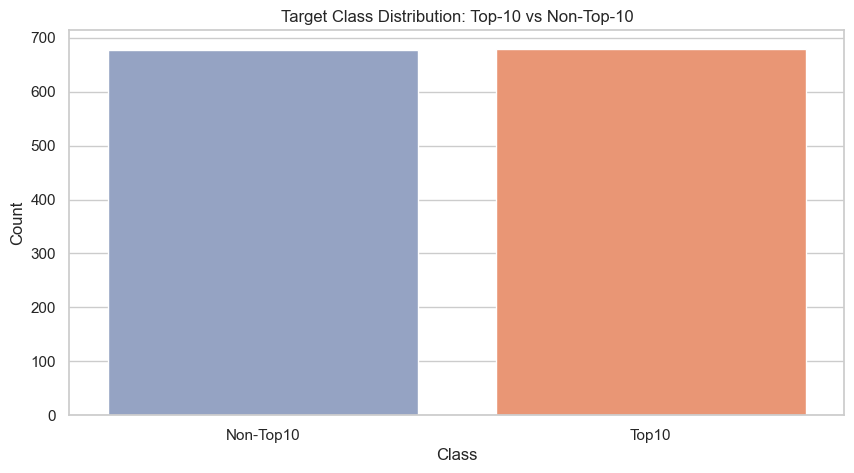

Majority-class baseline prediction: 1
Majority-class accuracy: 0.501
is_top10
Non-Top10    0.498895
Top10        0.501105
Name: proportion, dtype: float64


In [3]:
target_counts = df["is_top10"].value_counts().sort_index()
target_share = df["is_top10"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots()
sns.barplot(
    x=["Non-Top10", "Top10"],
    y=[target_counts.get(0, 0), target_counts.get(1, 0)],
    palette=["#8da0cb", "#fc8d62"],
    ax=ax
    )
ax.set_title("Target Class Distribution: Top-10 vs Non-Top-10")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

majority_class = int(target_counts.idxmax())
majority_acc = float(target_share.max())
print(f"Majority-class baseline prediction: {majority_class}")
print(f"Majority-class accuracy: {majority_acc:.3f}")
print(target_share.rename(index={0: 'Non-Top10', 1: 'Top10'}))

### Interpretation
The class distribution is expected to be close to balanced because exactly 10 out of ~20 drivers finish in Top 10 each race, but retirements and DSQ outcomes can distort the proportion slightly.

### Decision
Accuracy alone is insufficient for model quality claims. We will still report accuracy for the lab baseline, but interpret it with caution and compare it against a simple majority baseline.

## Question 2: How strongly does starting grid position influence the probability of finishing in the Top 10 in Formula 1 races?

### Data
We estimate Top-10 probability by starting grid position and compare it across grid buckets.

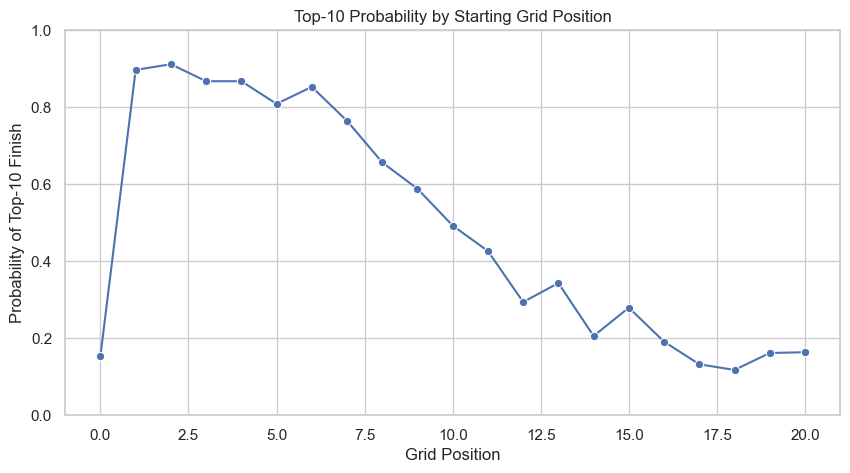

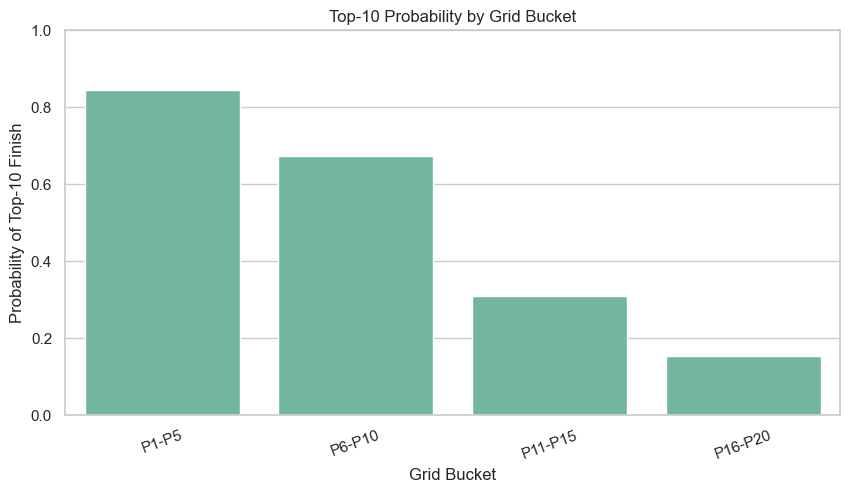

,grid_bucket,is_top10
0,P1-P5,0.844193
1,P6-P10,0.671598
2,P11-P15,0.309735
3,P16-P20,0.152905


In [13]:
q2_df = df.dropna(subset=["grid_position"]).copy()
q2_df["grid_bucket"] = pd.cut(
    q2_df["grid_position"],
    bins=[0, 5, 10, 15, 20],
    labels=["P1-P5", "P6-P10", "P11-P15", "P16-P20"],
    include_lowest=True
)

grid_prob = (
    q2_df.groupby("grid_position", as_index=False)["is_top10"]
    .mean()
    .sort_values("grid_position")
)

fig, ax = plt.subplots()
sns.lineplot(data=grid_prob, x="grid_position", y="is_top10", marker="o", ax=ax)
ax.set_title("Top-10 Probability by Starting Grid Position")
ax.set_xlabel("Grid Position")
ax.set_ylabel("Probability of Top-10 Finish")
ax.set_ylim(0, 1)
plt.show()

bucket_prob = (
    q2_df.groupby("grid_bucket", as_index=False, observed=False)["is_top10"]
    .mean()
    .sort_values("grid_bucket")
)

fig, ax = plt.subplots()
sns.barplot(data=bucket_prob, x="grid_bucket", y="is_top10", color="#66c2a5", ax=ax)
ax.set_title("Top-10 Probability by Grid Bucket")
ax.set_xlabel("Grid Bucket")
ax.set_ylabel("Probability of Top-10 Finish")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

bucket_prob

### Interpretation
A notable decline in Top-10 probability from front-grid positions to back-grid positions indicates a strong relationship between qualifying performance and race outcome.

### Decision
Grid position should remain one of the main pre-race features in the baseline because it carries clear predictive value without introducing leakage.

## Question 3: Is Top-10 behavior stable across seasons (2022, 2023, 2024), or do we observe temporal shift?

### Data
We compare yearly Top-10 rates and inspect whether key feature distributions (for example, grid position) shift over time.

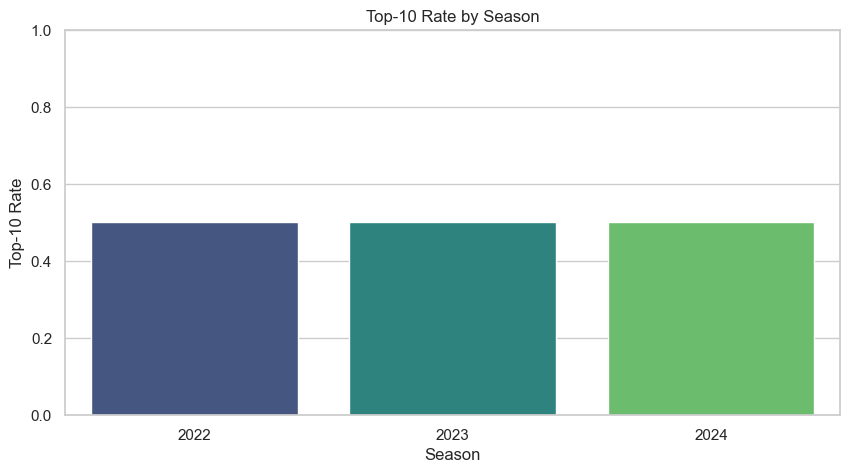

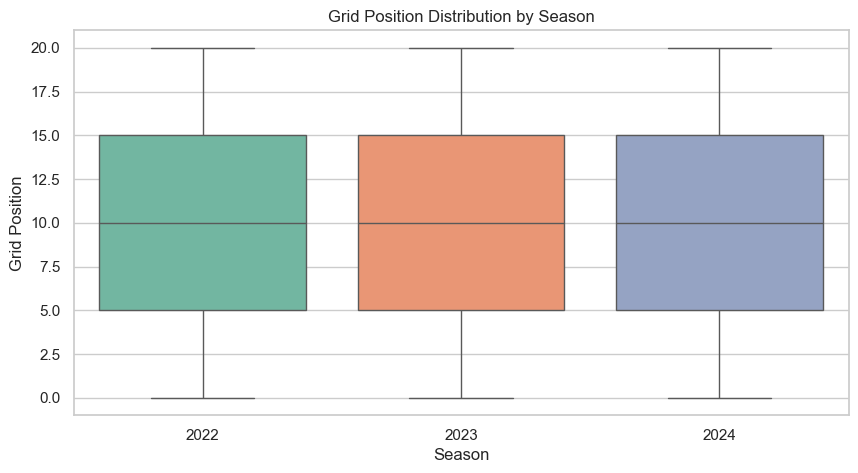

,season,is_top10
0,2022,0.501139
1,2023,0.501139
2,2024,0.501044


In [5]:
season_target = df.groupby("season", as_index=False)["is_top10"].mean()

fig, ax = plt.subplots()
sns.barplot(data=season_target, x="season", y="is_top10", palette="viridis", ax=ax)
ax.set_title("Top-10 Rate by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Top-10 Rate")
ax.set_ylim(0, 1)
plt.show()

fig, ax = plt.subplots()
sns.boxplot(data=df.dropna(subset=["grid_position"]), x="season", y="grid_position", palette="Set2", ax=ax)
ax.set_title("Grid Position Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Grid Position")
plt.show()

season_target

### Answer
If yearly Top-10 rates and feature distributions are similar, temporal stability is acceptable; if they differ materially, we should expect potential generalization risk across seasons.

### Decision
Use a temporal split (past -> future) and report season-aware findings instead of random-split assumptions.

## Question 4: Which teams are most associated with Top-10 finishes, and is this effect stable enough to matter?

### Data
We compute each team's Top-10 rate and sample size to avoid over-interpreting small samples.

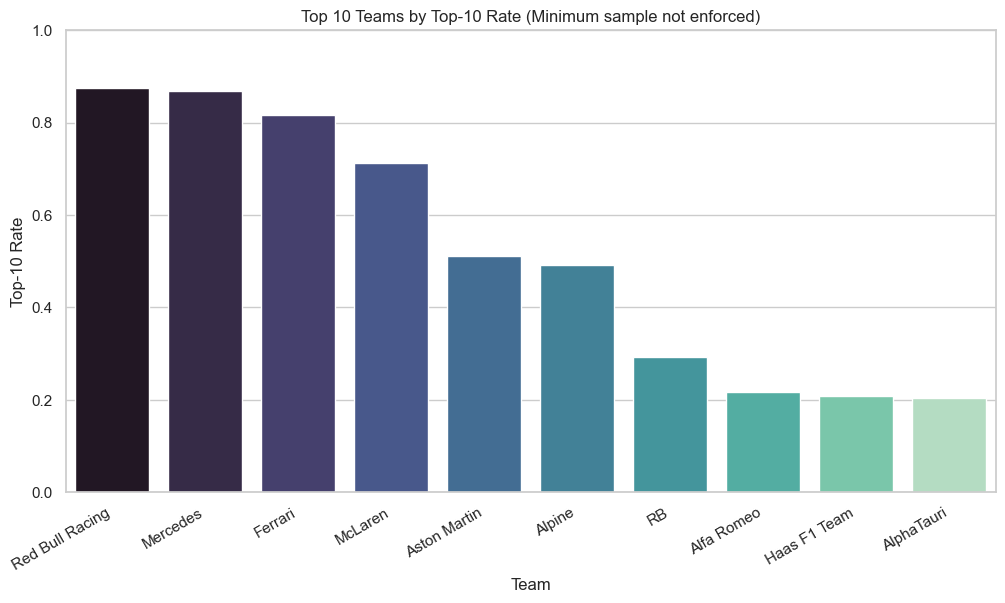

,team_name,top10_rate,races
10,Red Bull Racing,0.875000,136
8,Mercedes,0.867647,136
4,Ferrari,0.816176,136
7,McLaren,0.713235,136
3,Aston Martin,0.511111,135
2,Alpine,0.492647,136
9,RB,0.291667,48
0,Alfa Romeo,0.215909,88
5,Haas F1 Team,0.207407,135
1,AlphaTauri,0.204545,88


In [ ]:
team_perf = (
    df.groupby("team_name", as_index=False)
      .agg(top10_rate=("is_top10", "mean"), races=("is_top10", "size"))
      .sort_values(["top10_rate", "races"], ascending=[False, False])
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=team_perf.head(10), x="team_name", y="top10_rate", palette="mako", ax=ax)
ax.set_title("Top 10 Teams by Top-10 Rate (Minimum sample not enforced)")
ax.set_xlabel("Team")
ax.set_ylabel("Top-10 Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

team_perf.head(10)

### Answer
Top teams typically show consistently higher Top-10 rates, but interpretation must consider sample size and season effects.

### Decision
Team-level historical strength can be used as a contextual feature, but we should avoid ranking conclusions without sample-size checks.

## Question 5: Does prior form (driver and team historical Top-10 rate before each race) improve decision signal?

### Data
We compare Top-10 outcomes against pre-race historical rates computed with shifted expanding averages (no race-level leakage).

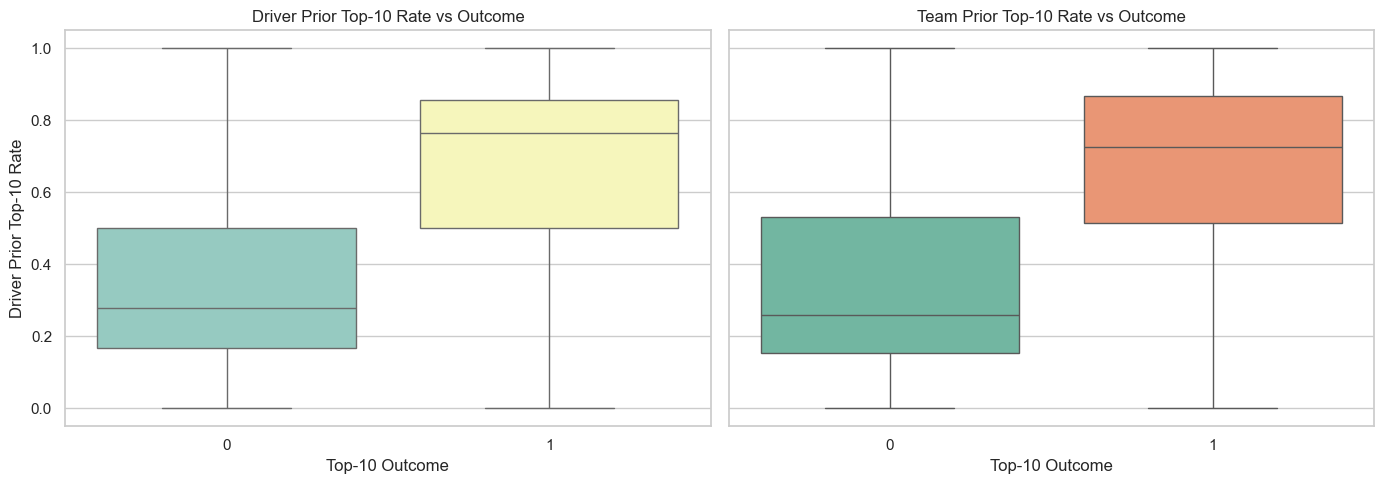

In [7]:
q5_df = df.sort_values(["driver_code", "season", "round"]).copy()
q5_df["driver_prior_top10_rate"] = (
    q5_df.groupby("driver_code")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

team_history = df.sort_values(["team_name", "season", "round"]).copy()
team_history["team_prior_top10_rate"] = (
    team_history.groupby("team_name")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

q5_df = q5_df.merge(
    team_history[["driver_code", "season", "round", "team_prior_top10_rate"]],
    on=["driver_code", "season", "round"],
    how="left"
    )

global_top10_rate = df["is_top10"].mean()
q5_df["driver_prior_top10_rate"] = q5_df["driver_prior_top10_rate"].fillna(global_top10_rate)
q5_df["team_prior_top10_rate"] = q5_df["team_prior_top10_rate"].fillna(global_top10_rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.boxplot(data=q5_df, x="is_top10", y="driver_prior_top10_rate", palette="Set3", ax=axes[0])
axes[0].set_title("Driver Prior Top-10 Rate vs Outcome")
axes[0].set_xlabel("Top-10 Outcome")
axes[0].set_ylabel("Driver Prior Top-10 Rate")

sns.boxplot(data=q5_df, x="is_top10", y="team_prior_top10_rate", palette="Set2", ax=axes[1])
axes[1].set_title("Team Prior Top-10 Rate vs Outcome")
axes[1].set_xlabel("Top-10 Outcome")
axes[1].set_ylabel("Team Prior Top-10 Rate")

plt.tight_layout()
plt.show()

### Answer
If drivers and teams with stronger historical Top-10 rates also tend to finish in the Top 10 more often, prior form provides a useful decision signal.

### Decision
Historical performance should be considered in later modeling, but it should be created carefully inside the analysis so it only uses information from previous races.

## Correlation Analysis (At least 5 candidate features)

### Data
We use Spearman correlation with `is_top10` because several variables are ordinal or not strictly linear.

In [ ]:
corr_df = df.sort_values(["driver_code", "season", "round"]).copy()
corr_df["driver_prior_top10_rate"] = (
    corr_df.groupby("driver_code")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

team_corr_df = df.sort_values(["team_name", "season", "round"]).copy()
team_corr_df["team_prior_top10_rate"] = (
    team_corr_df.groupby("team_name")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

corr_df = corr_df.merge(
    team_corr_df[["driver_code", "season", "round", "team_prior_top10_rate"]],
    on=["driver_code", "season", "round"],
    how="left"
    )

global_top10_rate = df["is_top10"].mean()
corr_df["driver_prior_top10_rate"] = corr_df["driver_prior_top10_rate"].fillna(global_top10_rate)
corr_df["team_prior_top10_rate"] = corr_df["team_prior_top10_rate"].fillna(global_top10_rate)

corr_features = [
    "grid_position",
    "round",
    "season",
    "driver_prior_top10_rate",
    "team_prior_top10_rate",
    "points",
 ]

corr_matrix = corr_df[corr_features + ["is_top10"]].corr(method="spearman")
target_corr = (
    corr_matrix["is_top10"]
    .drop("is_top10")
    .sort_values(ascending=False)
    .rename("spearman_corr_with_is_top10")
)
display(target_corr.to_frame())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Spearman Correlation Matrix")
plt.show()

KeyError: "['points'] not in index"

### Answer
The sign of the correlation tells us whether a feature moves with or against Top-10 outcomes, while the magnitude tells us how strong that relationship is. Grid position should be negatively related, historical form should be positively related, and points should look artificially strong because it is only known after the race.

### Decision
Keep pre-race variables for honest prediction and use the strong post-race relationship of `points` only as evidence of leakage risk, not as a usable feature.

## Trap Awareness Check (Spurious Correlation / Leakage Trap)

### Check performed
We compare a pre-race feature (`grid_position`) against a post-race feature (`points`) to demonstrate why strong correlation can be misleading for prediction.

In [ ]:
trap_corr = df[["is_top10", "grid_position", "points"]].corr(method="spearman")
print(trap_corr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="grid_position", y="is_top10", alpha=0.3, ax=axes[0])
axes[0].set_title("Pre-race feature: Grid vs Top-10")
axes[0].set_xlabel("Grid Position")
axes[0].set_ylabel("Top-10 (0/1)")

sns.scatterplot(data=df, x="points", y="is_top10", alpha=0.3, ax=axes[1], color="#fc8d62")
axes[1].set_title("Post-race feature: Points vs Top-10")
axes[1].set_xlabel("Points (post-race)")
axes[1].set_ylabel("Top-10 (0/1)")

plt.tight_layout()
plt.show()

### Finding
A post-race variable like `points` can show very strong correlation with the target because it is generated after the race outcome is known.

### Decision
We explicitly classify `points`, `finish_position`, and race status outcomes as leakage-prone for pre-race prediction and exclude them from baseline/model inputs.

## Explicit Temporal Train / Validation / Test Split

### Proposed split
- **Train:** 2022 season
- **Validation:** 2023 season
- **Test:** 2024 season

### Rationale
- Respects time order (past -> future).
- Prevents leakage from future races into earlier training stages.
- Simulates realistic deployment where we predict unseen future races.
- Enables honest comparison against a domain baseline on validation before touching test.

In [ ]:
split_counts = (
    df.assign(
        split=np.select(
            [df["season"] == 2022, df["season"] == 2023, df["season"] == 2024],
            ["train", "validation", "test"],
            default="other"
        )
    )
    .groupby(["split", "is_top10"], as_index=False)
    .size()
)
split_counts

## Data Quality Audit

### Scope
This audit checks missing values, data types, outliers, and temporal availability (pre-race vs post-race).

In [ ]:
missing_summary = (
    df[["grid_position", "finish_position", "classified_position", "status", "points"]]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
display(missing_summary)

dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dt) for dt in df.dtypes],
    "unique_values": [df[col].nunique(dropna=False) for col in df.columns],
}).sort_values("column")
display(dtype_summary.head(15))

grid_values = df["grid_position"].dropna()
invalid_grid_rate = ((grid_values < 1) | (grid_values > 20)).mean()
print(f"Invalid grid-position rate outside 1-20: {invalid_grid_rate:.3f}")

### Data quality findings (structured for DATA_QUALITY_LOG.md)

1. **`grid_position` missing values**
- Classification: MAR
- Impact: reduces coverage for a key pre-race feature
- Decision: keep the rows in EDA and handle missing values explicitly in the baseline if needed

2. **`classified_position` formatting issues**
- Classification: Type / encoding issue
- Impact: some race outcomes may appear as strings instead of clean numeric values
- Decision: use `finish_position` as the main numeric outcome field for analysis

3. **`status` is descriptive text rather than a clean analytical variable**
- Classification: Type / semantic issue
- Impact: useful for interpretation but not directly suitable as a numeric feature
- Decision: keep it for context, not as a main predictive feature

4. **`points` is available only after the race**
- Classification: Temporal availability / leakage
- Impact: it can artificially inflate apparent predictive power
- Decision: exclude it from any pre-race baseline or model

5. **Unexpected `grid_position` values outside the normal 1-20 range**
- Classification: Domain validity / outlier check
- Impact: can distort plots and correlations if not inspected
- Decision: flag these records and verify whether they reflect pit-lane starts or data issues

## Temporal Availability Audit (Pre-race vs Post-race)

- **Pre-race candidate features:** `grid_position`, `season`, `round`, team identity, driver identity, and historical rates built only from previous races
- **Post-race (leakage) features:** `finish_position`, `points`, and detailed final race outcomes
- **Rule for baseline/modeling:** only use information that would be known before lights out

## Final 1-3-1 Summary

**1 Headline (decision)**
Starting grid position and prior race history provide enough pre-race signal to justify a simple, leakage-safe Top-10 baseline.

**3 Evidence points**
1. Drivers starting closer to the front have a much higher chance of finishing in the Top 10.
2. Historical Top-10 rates for drivers and teams separate stronger outcomes from weaker ones.
3. Post-race variables such as points look highly predictive, but they are unusable for honest pre-race prediction because they leak the result.

**1 Action**
Build the baseline in baseline.ipynb with a pre-race rule such as `grid_position <= 10`, validate it on 2023, and treat that score as the minimum bar for future models.